In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'torch', 'torchvision', 'scikit-learn',
                       'matplotlib', 'tqdm', 'scipy', '-q'])
print('✅ Dependencies ready')

✅ Dependencies ready



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import urllib.request

print(urllib.request.urlopen("https://www.google.com").status)

200


In [3]:
# ── Cell 2: Local dataset path ───────────────────────────────────
import os

DATA_DIR = "/Users/yashsinghrawat/SMS-LiRA/results"
OUT_DIR = "./output"

os.makedirs(OUT_DIR, exist_ok=True)

print(f"DATA_DIR : {DATA_DIR}")
print(f"OUT_DIR  : {OUT_DIR}")

print("\nFiles in DATA_DIR:")
for f in sorted(os.listdir(DATA_DIR)):
    mb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1e6
    print(f"  {f:<40s} {mb:7.1f} MB")

DATA_DIR : /Users/yashsinghrawat/SMS-LiRA/results
OUT_DIR  : ./output

Files in DATA_DIR:
  config.json                                  0.0 MB
  nonmember_idx.json                           0.0 MB
  shadow_losses.npy                            0.1 MB
  shadow_membership.npy                        0.0 MB
  shadow_model_1.pth                         170.6 MB
  shadow_model_2.pth                         170.6 MB
  target_idx.json                              0.0 MB
  target_model.pth                           170.6 MB
  target_sample_idx.json                       0.0 MB


In [4]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

print("SSL verification disabled")

SSL verification disabled


In [5]:
# ── Cell 3: Imports ───────────────────────────────────────────────
import os, json, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import norm
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from tqdm.auto import tqdm
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

def make_schedule(T=1000, beta_start=1e-4, beta_end=0.02, dev='cpu'):
    betas = torch.linspace(beta_start, beta_end, T, device=dev)
    return torch.cumprod(1.0 - betas, dim=0)

print('✅ Imports done')

/Users/yashsinghrawat/SMS-LiRA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
✅ Imports done


In [6]:
import os

DATA_DIR = "/Users/yashsinghrawat/SMS-LiRA/results"

print("Exists:", os.path.exists(DATA_DIR))
print("\nFiles:")
for f in sorted(os.listdir(DATA_DIR)):
    print(f)

Exists: True

Files:
config.json
nonmember_idx.json
shadow_losses.npy
shadow_membership.npy
shadow_model_1.pth
shadow_model_2.pth
target_idx.json
target_model.pth
target_sample_idx.json


In [7]:
# ── Cell 4: ImprovedUNet — MUST exactly match mia_code/model.py ───

def _norm(channels):
    groups = min(32, channels)
    while channels % groups != 0:
        groups //= 2
    return nn.GroupNorm(groups, channels)

class SinusoidalPE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        args = t[:, None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, dropout=0.1):
        super().__init__()
        self.norm1     = _norm(in_ch)
        self.conv1     = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(t_dim, 2 * out_ch)
        self.norm2     = _norm(out_ch)
        self.dropout   = nn.Dropout(dropout)
        self.conv2     = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.residual  = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        scale, shift = self.time_proj(F.silu(t_emb)).chunk(2, dim=1)
        h = self.norm2(h) * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = self.conv2(self.dropout(F.silu(h)))
        return h + self.residual(x)

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, channels, n_heads=4):
        super().__init__()
        self.norm = _norm(channels)
        self.attn = nn.MultiheadAttention(channels, n_heads, batch_first=True)
        self.proj = nn.Conv2d(channels, channels, 1)
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).view(B, C, H * W).permute(0, 2, 1)
        h, _ = self.attn(h, h, h, need_weights=False)
        return x + self.proj(h.permute(0, 2, 1).view(B, C, H, W))

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, has_attn=False, dropout=0.1):
        super().__init__()
        self.res1 = ResBlock(in_ch,  out_ch, t_dim, dropout)
        self.res2 = ResBlock(out_ch, out_ch, t_dim, dropout)
        self.attn = MultiHeadSelfAttention(out_ch) if has_attn else nn.Identity()
        self.down = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)
    def forward(self, x, t):
        x = self.res1(x, t)
        x = self.res2(x, t)
        x = self.attn(x) if isinstance(self.attn, MultiHeadSelfAttention) else self.attn(x)
        return self.down(x), x

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, t_dim, has_attn=False, dropout=0.1):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch, 4, stride=2, padding=1)
        self.res1 = ResBlock(in_ch + skip_ch, out_ch, t_dim, dropout)
        self.res2 = ResBlock(out_ch,          out_ch, t_dim, dropout)
        self.attn = MultiHeadSelfAttention(out_ch) if has_attn else nn.Identity()
    def forward(self, x, skip, t):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:])
        x = torch.cat([x, skip], dim=1)
        x = self.res1(x, t)
        x = self.res2(x, t)
        return self.attn(x) if isinstance(self.attn, MultiHeadSelfAttention) else self.attn(x)

class Bottleneck(nn.Module):
    def __init__(self, channels, t_dim, dropout=0.1):
        super().__init__()
        self.res1 = ResBlock(channels, channels, t_dim, dropout)
        self.attn = MultiHeadSelfAttention(channels)
        self.res2 = ResBlock(channels, channels, t_dim, dropout)
    def forward(self, x, t):
        x = self.res1(x, t)
        x = self.attn(x)
        return self.res2(x, t)

class ImprovedUNet(nn.Module):
    def __init__(self, image_channels=3, base_ch=128, t_dim=128, dropout=0.1):
        super().__init__()
        ch = base_ch
        inner_t = 4 * t_dim
        self.time_embed = nn.Sequential(
            SinusoidalPE(t_dim), nn.Linear(t_dim, inner_t), nn.SiLU(), nn.Linear(inner_t, inner_t)
        )
        self.stem  = nn.Conv2d(image_channels, ch, 3, padding=1)
        self.down0 = DownBlock(ch,     ch * 2, inner_t, has_attn=False, dropout=dropout)
        self.down1 = DownBlock(ch * 2, ch * 4, inner_t, has_attn=True,  dropout=dropout)
        self.mid   = Bottleneck(ch * 4, inner_t, dropout=dropout)
        self.up1   = UpBlock(ch * 4, ch * 4, ch * 2, inner_t, has_attn=True,  dropout=dropout)
        self.up0   = UpBlock(ch * 2, ch * 2, ch,     inner_t, has_attn=False, dropout=dropout)
        self.out_norm = _norm(ch)
        self.out_conv = nn.Conv2d(ch, image_channels, 1)
    def forward(self, x, timestep):
        t     = self.time_embed(timestep)
        x     = self.stem(x)
        x, s0 = self.down0(x, t)
        x, s1 = self.down1(x, t)
        x     = self.mid(x, t)
        x     = self.up1(x, s1, t)
        x     = self.up0(x, s0, t)
        return self.out_conv(F.silu(self.out_norm(x)))

n_params = sum(p.numel() for p in ImprovedUNet().parameters())
print(f'✅ ImprovedUNet defined | {n_params/1e6:.1f}M parameters')

✅ ImprovedUNet defined | 42.6M parameters


In [8]:
# ── Cell 5: Load metadata & pre-computed shadow data ──────────────
def jload(name):
    with open(os.path.join(DATA_DIR, name)) as f:
        return json.load(f)

cfg                 = jload('config.json')
target_sample_idx   = jload('target_sample_idx.json')   # 2K member indices
nonmember_idx       = jload('nonmember_idx.json')        # 2K non-member indices

t_sweep   = cfg['t_sweep']
t_lira    = cfg['t_lira']
t_strong  = cfg['t_strong']
n_repeats = cfg['n_repeats']
n_shadow  = cfg['n_shadow']
n_probe = len(target_sample_idx)
n_challenge = 2 * n_probe

print("n_probe =", n_probe)
print("n_challenge =", n_challenge)
ts_to_idx = {t: i for i, t in enumerate(t_sweep)}

for ts in t_strong:
    assert ts in ts_to_idx, f't_strong value {ts} not in t_sweep!'

print('Config:', cfg)

shadow_losses     = np.load(os.path.join(DATA_DIR, 'shadow_losses.npy'))
shadow_membership = np.load(os.path.join(DATA_DIR, 'shadow_membership.npy'))

# Layout: column [0:n_probe] = members  |  [n_probe:2*n_probe] = non-members
n_challenge = 2 * n_probe
print(f'shadow_losses     : {shadow_losses.shape}  (expected ({n_shadow}, {len(t_sweep)}, {n_challenge}))')
print(f'shadow_membership : {shadow_membership.shape}  (expected ({n_shadow}, {n_challenge}))')

# ── Crash-safe: accept partial runs ───────────────────────────────
n_shadow_saved = shadow_losses.shape[0]
if n_shadow_saved < n_shadow:
    print(f'WARNING: Only {n_shadow_saved}/{n_shadow} shadows in volume.'
          f' Using {n_shadow_saved} shadows for evaluation.')
    n_shadow = n_shadow_saved
    shadow_losses     = shadow_losses[:n_shadow]
    shadow_membership = shadow_membership[:n_shadow]

# Sanity check: membership should be ~50% for all columns
mem_rate = shadow_membership.mean()
assert 0.35 < mem_rate < 0.65, f'membership rate {mem_rate:.3f} looks wrong (expected ~0.50)'

print(f'\nMembership rate : {mem_rate:.3f}  (expect ~0.50 ✅)')
print(f'Member range  [0:{n_probe}]  |  Non-member range [{n_probe}:{n_challenge}]')
print('✅ All data loaded and verified')

n_probe = 500
n_challenge = 1000
Config: {'n_total': 5000, 'target_frac': 0.5, 'n_eval': 500, 'n_nonmember': 500, 'n_shadow': 2, 'shadow_frac': 0.5, 'target_epochs': 10, 'shadow_epochs': 5, 'batch_size': 16, 'lr': 0.0002, 'weight_decay': 0.0001, 'grad_clip': 1.0, 'print_every': 20, 'T': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 't_sweep': [1, 5, 10, 50, 75, 100, 150, 200, 300, 400, 500, 750, 999], 't_lira': 100, 't_strong': [50, 100, 150, 200], 'n_repeats': 50, 'n_probe': 2000}
shadow_losses     : (2, 13, 1000)  (expected (2, 13, 1000))
shadow_membership : (2, 1000)  (expected (2, 1000))

Membership rate : 0.494  (expect ~0.50 ✅)
Member range  [0:500]  |  Non-member range [500:1000]
✅ All data loaded and verified


In [9]:
import os

DATA_DIR = "/Users/yashsinghrawat/SMS-LiRA/results"
OUT_DIR = "./output"

print("DATA_DIR =", DATA_DIR)
print("Exists:", os.path.exists(DATA_DIR))

DATA_DIR = /Users/yashsinghrawat/SMS-LiRA/results
Exists: True


In [10]:
# ── Cell 6: Build challenge set ───────────────────────────────────
tf    = T.Compose([T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)])
cifar = torchvision.datasets.CIFAR10('/tmp/cifar10', train=True, download=True, transform=tf)

def load_subset(indices):
    loader = DataLoader(Subset(cifar, indices), batch_size=512,
                        shuffle=False, num_workers=0)
    return torch.cat([xb for xb, _ in loader], dim=0)

print(f'Loading {n_probe} member images …')
members_x    = load_subset(target_sample_idx[:n_probe])
print(f'Loading {n_probe} non-member images …')
nonmembers_x = load_subset(nonmember_idx[:n_probe])

all_x  = torch.cat([members_x, nonmembers_x], dim=0)  # shape: (2*n_probe, 3, 32, 32)
labels = np.array([1]*n_probe + [0]*n_probe, dtype=np.int32)

assert all_x.shape == (n_challenge, 3, 32, 32)
print(f'✅ Challenge set: {len(all_x)} total  ({n_probe} members + {n_probe} non-members)')

Loading 500 member images …
Loading 500 non-member images …
✅ Challenge set: 1000 total  (500 members + 500 non-members)


In [11]:
print("n_probe =", n_probe)
print("n_challenge =", n_challenge)

print("members_x shape =", members_x.shape)
print("nonmembers_x shape =", nonmembers_x.shape)
print("all_x shape =", all_x.shape)

n_probe = 500
n_challenge = 1000
members_x shape = torch.Size([500, 3, 32, 32])
nonmembers_x shape = torch.Size([500, 3, 32, 32])
all_x shape = torch.Size([1000, 3, 32, 32])


In [12]:
print("members_x shape:", members_x.shape)
print("nonmembers_x shape:", nonmembers_x.shape)
print("all_x shape:", all_x.shape)

print("n_probe =", n_probe)
print("n_challenge =", n_challenge)

members_x shape: torch.Size([500, 3, 32, 32])
nonmembers_x shape: torch.Size([500, 3, 32, 32])
all_x shape: torch.Size([1000, 3, 32, 32])
n_probe = 500
n_challenge = 1000


In [13]:
print("members_x shape:", members_x.shape)
print("nonmembers_x shape:", nonmembers_x.shape)
print("all_x shape:", all_x.shape)

print("n_probe =", n_probe)
print("n_challenge =", n_challenge)

print("target_sample_idx =", len(target_sample_idx))
print("nonmember_idx =", len(nonmember_idx))

members_x shape: torch.Size([500, 3, 32, 32])
nonmembers_x shape: torch.Size([500, 3, 32, 32])
all_x shape: torch.Size([1000, 3, 32, 32])
n_probe = 500
n_challenge = 1000
target_sample_idx = 500
nonmember_idx = 500


In [14]:
print(type(target_sample_idx))
print(type(nonmember_idx))

print("target_sample_idx length:", len(target_sample_idx))
print("nonmember_idx length:", len(nonmember_idx))

print("first 10 target indices:", target_sample_idx[:10])
print("first 10 nonmember indices:", nonmember_idx[:10])

<class 'list'>
<class 'list'>
target_sample_idx length: 500
nonmember_idx length: 500
first 10 target indices: [4840, 4587, 3335, 4432, 3120, 4527, 4994, 2255, 2546, 2866]
first 10 nonmember indices: [942, 3705, 237, 4673, 2264, 4170, 4164, 927, 3896, 1279]


In [15]:
print(cfg)

{'n_total': 5000, 'target_frac': 0.5, 'n_eval': 500, 'n_nonmember': 500, 'n_shadow': 2, 'shadow_frac': 0.5, 'target_epochs': 10, 'shadow_epochs': 5, 'batch_size': 16, 'lr': 0.0002, 'weight_decay': 0.0001, 'grad_clip': 1.0, 'print_every': 20, 'T': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 't_sweep': [1, 5, 10, 50, 75, 100, 150, 200, 300, 400, 500, 750, 999], 't_lira': 100, 't_strong': [50, 100, 150, 200], 'n_repeats': 50, 'n_probe': 2000}


In [16]:
import os

print("Files in DATA_DIR:")
for f in sorted(os.listdir(DATA_DIR)):
    print(f)

Files in DATA_DIR:
config.json
nonmember_idx.json
shadow_losses.npy
shadow_membership.npy
shadow_model_1.pth
shadow_model_2.pth
target_idx.json
target_model.pth
target_sample_idx.json


In [17]:
# ── Cell 7: Load target model ─────────────────────────────────────
model = ImprovedUNet().to(device)
state = torch.load(os.path.join(DATA_DIR, 'target_model.pth'), map_location=device)
model.load_state_dict(state)
model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(f'✅ Target model loaded | {n_params/1e6:.1f}M parameters')
alpha_bar = make_schedule(cfg['T'], cfg['beta_start'], cfg['beta_end'], dev=device)
print(f'   alpha_bar: {alpha_bar.shape}')

✅ Target model loaded | 42.6M parameters
   alpha_bar: torch.Size([1000])


In [18]:
# ── Cell 8: Evaluation helper (with horizontal flip augmentation) ──
@torch.no_grad()
def eval_target(x_cpu, timesteps, n_queries=1, use_flip=False,
                batch_size=256, desc='eval', checkpoint_path=None):
    """
    Evaluate target model losses.
    use_flip=True: averages loss over original + horizontally flipped image.
                   Paper's Strong LiRA uses this to reduce variance.
    """
    N      = x_cpu.shape[0]
    result = np.zeros((len(timesteps), N), dtype=np.float32)
    model.eval()
    for ti, t_val in enumerate(tqdm(timesteps, desc=desc)):
        t_val = min(t_val, alpha_bar.shape[0] - 1)
        ab    = alpha_bar[t_val]
        col   = []
        for start in range(0, N, batch_size):
            xb       = x_cpu[start:start+batch_size].to(device)
            bs       = xb.size(0)
            t_tensor = torch.full((bs,), t_val, device=device, dtype=torch.long)
            q_losses = []
            for _ in range(n_queries):
                noise = torch.randn_like(xb)
                xt    = ab.sqrt() * xb + (1 - ab).sqrt() * noise
                pred  = model(xt, t_tensor)
                lp    = ((pred - noise) ** 2).mean(dim=[1, 2, 3])

                if use_flip:
                    # Horizontal flip augmentation: same noise, flipped image
                    xb_f   = torch.flip(xb, dims=[-1])
                    xt_f   = ab.sqrt() * xb_f + (1 - ab).sqrt() * noise
                    pred_f = model(xt_f, t_tensor)
                    lp_f   = ((pred_f - noise) ** 2).mean(dim=[1, 2, 3])
                    lp     = (lp + lp_f) / 2.0   # average original + flipped

                q_losses.append(lp)
            col.append(torch.stack(q_losses).mean(0).cpu().numpy())
        result[ti] = np.concatenate(col)
        if checkpoint_path:
            np.save(checkpoint_path, result)
    return result

print('✅ eval_target() defined  (supports horizontal flip augmentation)')

✅ eval_target() defined  (supports horizontal flip augmentation)


In [19]:
# ── Cell 9: Pass 1 — sweep losses (1 query, no flip) ─────────────
CKPT_1Q = os.path.join(OUT_DIR, 'tgt_losses_1q.npy')
if os.path.exists(CKPT_1Q):
    print('Loading cached 1-query losses …')
    tgt_losses_1q = np.load(CKPT_1Q)
else:
    t0 = time.time()
    tgt_losses_1q = eval_target(all_x, t_sweep, n_queries=1, use_flip=False,
                                desc='Pass1 sweep/LiRA', checkpoint_path=CKPT_1Q)
    print(f'✅ Pass 1 done in {(time.time()-t0)/60:.1f} min')
print(f'Shape: {tgt_losses_1q.shape}  (expected ({len(t_sweep)}, {n_challenge}))')
assert tgt_losses_1q.shape == (len(t_sweep), n_challenge)

Loading cached 1-query losses …
Shape: (13, 1000)  (expected (13, 1000))


In [20]:
n_repeats = 1
t_strong = [50]

print("Demo mode enabled")

Demo mode enabled


In [21]:
# ── Cell 10: Pass 2 — Strong LiRA (n_repeats queries + flip aug) ──
CKPT_STRONG = os.path.join(OUT_DIR, 'tgt_losses_strong.npy')
if os.path.exists(CKPT_STRONG):
    print('Loading cached strong losses …')
    tgt_losses_strong = np.load(CKPT_STRONG)
else:
    t0 = time.time()
    tgt_losses_strong = eval_target(all_x, t_strong, n_queries=n_repeats,
                                    use_flip=True,   # ← horizontal flip aug
                                    desc='Pass2 Strong LiRA',
                                    checkpoint_path=CKPT_STRONG)
    print(f'✅ Pass 2 done in {(time.time()-t0)/60:.1f} min')
print(f'Shape: {tgt_losses_strong.shape}  (expected ({len(t_strong)}, {n_challenge}))')
assert tgt_losses_strong.shape == (len(t_strong), n_challenge)

Loading cached strong losses …
Shape: (1, 1000)  (expected (1, 1000))


In [22]:
# ── Cell 11: Build out-shadow means (SIMPLIFIED in v2) ────────────
# In v2, shadow_membership covers ALL 4K challenge samples uniformly.
# For each sample n, out-shadows = shadows that did NOT train on n.
# This now works correctly for BOTH members and non-members.

def build_out_mean(shadow_mat, membership):
    """
    shadow_mat : (n_sh, n_ts, N)  float32
    membership : (n_sh, N)        bool  — True if shadow trained on sample n
    Returns    : (n_ts, N)        float32 — mean loss from out-shadows
    """
    n_sh, n_ts, N = shadow_mat.shape
    out = np.zeros((n_ts, N), dtype=np.float32)
    for n in range(N):
        mask = ~membership[:, n]   # out-shadows: did NOT train on sample n
        if mask.any():
            out[:, n] = shadow_mat[mask, :, n].mean(axis=0)
        else:
            out[:, n] = shadow_mat[:, :, n].mean(axis=0)  # fallback (rare)
    return out

print('Building out-shadow means for all challenge samples …')
out_mean_all = build_out_mean(shadow_losses, shadow_membership)  # (n_ts, 4K)

print(f'out_mean_all shape: {out_mean_all.shape}  (expected ({len(t_sweep)}, {n_challenge}))')
assert out_mean_all.shape == (len(t_sweep), n_challenge)

# Verify: out-shadow mean should be higher for members than non-members
ti_lira = ts_to_idx[t_lira]
mean_mem_out    = out_mean_all[ti_lira, :n_probe].mean()
mean_nonmem_out = out_mean_all[ti_lira, n_probe:].mean()
print(f'  Out-shadow mean (members)     : {mean_mem_out:.4f}')
print(f'  Out-shadow mean (non-members) : {mean_nonmem_out:.4f}')
print(f'  Ratio                         : {mean_mem_out / mean_nonmem_out:.3f}  (expect ≈ 1.0)')
print('✅ Out-shadow means ready')

Building out-shadow means for all challenge samples …
out_mean_all shape: (13, 1000)  (expected (13, 1000))
  Out-shadow mean (members)     : 0.1057
  Out-shadow mean (non-members) : 0.1062
  Ratio                         : 0.995  (expect ≈ 1.0)
✅ Out-shadow means ready


In [23]:
# ── Cell 12: N_IN vs N_OUT Distribution Plot ──────────────────────
# For each sample n:
#   N_IN  = losses from shadow models that TRAINED on n  (membership=True)
#   N_OUT = losses from shadow models that did NOT train on n (membership=False)
# Wider gap + smaller overlap → stronger attack → weaker privacy

def plot_loss_distributions(in_losses, out_losses, title, ax):
    mu_in,  std_in  = np.mean(in_losses),  np.std(in_losses)  + 1e-9
    mu_out, std_out = np.mean(out_losses), np.std(out_losses) + 1e-9
    x_lo = min(mu_in - 3.5*std_in,  mu_out - 3.5*std_out)
    x_hi = max(mu_in + 3.5*std_in,  mu_out + 3.5*std_out)
    x    = np.linspace(x_lo, x_hi, 300)
    pdf_in  = norm.pdf(x, mu_in,  std_in)
    pdf_out = norm.pdf(x, mu_out, std_out)
    ax.plot(x, pdf_in,  'b-', linewidth=2.2, label=f'$N_{{IN}}$  μ={mu_in:.4f}')
    ax.plot(x, pdf_out, 'r-', linewidth=2.2, label=f'$N_{{OUT}}$ μ={mu_out:.4f}')
    overlap = np.minimum(pdf_in, pdf_out)
    ax.fill_between(x, overlap, alpha=0.25, color='purple', label='Overlap (privacy zone)')
    ax.axvline(mu_in,  color='blue', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(mu_out, color='red',  linestyle='--', alpha=0.5, linewidth=1)
    ax.set_xlabel('Diffusion Loss', fontsize=11)
    ax.set_ylabel('Probability Density', fontsize=11)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ti = ts_to_idx[t_lira]

# Pick 6 samples: 3 members + 3 non-members with good in/out split
def pick_samples(start, end, n=3):
    chosen = []
    for idx in range(start, end):
        n_in  = shadow_membership[:, idx].sum()
        n_out = n_shadow - n_in
        if n_in >= 3 and n_out >= 3:
            chosen.append(idx)
        if len(chosen) == n:
            break
    return chosen

member_samples    = pick_samples(0,       n_probe,     n=3)
nonmember_samples = pick_samples(n_probe, n_challenge, n=3)
chosen_all        = member_samples + nonmember_samples
row_labels = ['Member'] * 3 + ['Non-Member'] * 3

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    f'N_IN vs N_OUT Loss Distributions at t={t_lira}\n'
    f'(v2: shadows trained on same 50K universe — proper N_IN for all samples)',
    fontsize=13, fontweight='bold'
)

for ax, idx, role in zip(axes.flat, chosen_all, row_labels):
    mask_in    = shadow_membership[:, idx]
    in_losses  = shadow_losses[mask_in,  ti, idx]
    out_losses = shadow_losses[~mask_in, ti, idx]
    gap = abs(np.mean(out_losses) - np.mean(in_losses))
    plot_loss_distributions(
        in_losses, out_losses,
        f'[{role}] col_idx={idx}  n_in={mask_in.sum()}/n_out={(~mask_in).sum()}  gap={gap:.4f}',
        ax
    )

plt.tight_layout()
DIST_PATH = os.path.join(OUT_DIR, 'loss_distributions.png')
plt.savefig(DIST_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Distribution plot saved → {DIST_PATH}')

✅ Distribution plot saved → ./output/loss_distributions.png


/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_3711/3339447245.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [24]:
# ── Cell 13: Compute attack scores ────────────────────────────────
lira_ti = ts_to_idx[t_lira]

# Threshold: low target loss → likely member → negate for score
thresh_score = -tgt_losses_1q[lira_ti]

# LiRA: out-shadow mean (calibrated) minus target loss
# Higher score → target loss is LOW relative to what out-shadows predict → member
lira_score = out_mean_all[lira_ti] - tgt_losses_1q[lira_ti]

# Strong LiRA: sum LLR across t_strong timesteps (with flip aug in Pass 2)
strong_score = np.zeros(n_challenge, dtype=np.float32)
for k, t_val in enumerate(t_strong):
    ti_sweep       = ts_to_idx[t_val]
    strong_score  += out_mean_all[ti_sweep] - tgt_losses_strong[k]

print('Attack scores computed:')
print(f'  Threshold   range : [{thresh_score.min():.4f}, {thresh_score.max():.4f}]')
print(f'  LiRA        range : [{lira_score.min():.4f},  {lira_score.max():.4f}]')
print(f'  Strong LiRA range : [{strong_score.min():.4f}, {strong_score.max():.4f}]')

np.savez(os.path.join(OUT_DIR, 'attack_scores.npz'),
         thresh=thresh_score, lira=lira_score,
         strong=strong_score, labels=labels)
print('✅ Scores saved')

Attack scores computed:
  Threshold   range : [-0.2470, -0.0259]
  LiRA        range : [-0.0157,  0.0659]
  Strong LiRA range : [-0.0295, 0.0638]
✅ Scores saved


In [25]:
# ── Cell 14: ROC curves + timestep sweep ─────────────────────────
def tpr_at_fpr(fpr_arr, tpr_arr, target=0.01):
    return float(np.interp(target, fpr_arr, tpr_arr))

sweep_tpr_lira, sweep_tpr_thresh = [], []
for ti, t_val in enumerate(t_sweep):
    fpr, tpr, _ = roc_curve(labels, out_mean_all[ti] - tgt_losses_1q[ti])
    sweep_tpr_lira.append(tpr_at_fpr(fpr, tpr))
    fpr, tpr, _ = roc_curve(labels, -tgt_losses_1q[ti])
    sweep_tpr_thresh.append(tpr_at_fpr(fpr, tpr))

fpr_thresh, tpr_thresh, _ = roc_curve(labels, thresh_score)
fpr_lira,   tpr_lira,   _ = roc_curve(labels, lira_score)
fpr_strong, tpr_strong, _ = roc_curve(labels, strong_score)
auc_thresh = roc_auc_score(labels, thresh_score)
auc_lira   = roc_auc_score(labels, lira_score)
auc_strong = roc_auc_score(labels, strong_score)

print('─' * 65)
print(f'Best TPR@FPR=1%  LiRA      : {max(sweep_tpr_lira):.4f}  '
      f'@ t={t_sweep[int(np.argmax(sweep_tpr_lira))]}')
print(f'Best TPR@FPR=1%  Threshold : {max(sweep_tpr_thresh):.4f}  '
      f'@ t={t_sweep[int(np.argmax(sweep_tpr_thresh))]}')
print('─' * 65)
print(f'ROC AUC  Strong LiRA : {auc_strong:.4f}')
print(f'ROC AUC  LiRA        : {auc_lira:.4f}')
print(f'ROC AUC  Threshold   : {auc_thresh:.4f}')

np.save(os.path.join(OUT_DIR, 't_sweep.npy'),          np.array(t_sweep))
np.save(os.path.join(OUT_DIR, 'sweep_tpr_lira.npy'),   np.array(sweep_tpr_lira))
np.save(os.path.join(OUT_DIR, 'sweep_tpr_thresh.npy'), np.array(sweep_tpr_thresh))
np.savez(os.path.join(OUT_DIR, 'roc_curves.npz'),
         fpr_strong=fpr_strong, tpr_strong=tpr_strong, auc_strong=np.float32(auc_strong),
         fpr_lira=fpr_lira,     tpr_lira=tpr_lira,     auc_lira=np.float32(auc_lira),
         fpr_thresh=fpr_thresh, tpr_thresh=tpr_thresh,  auc_thresh=np.float32(auc_thresh))
print('✅ ROC + sweep results saved')

─────────────────────────────────────────────────────────────────
Best TPR@FPR=1%  LiRA      : 0.0280  @ t=10
Best TPR@FPR=1%  Threshold : 0.0180  @ t=1
─────────────────────────────────────────────────────────────────
ROC AUC  Strong LiRA : 0.5092
ROC AUC  LiRA        : 0.5144
ROC AUC  Threshold   : 0.5100
✅ ROC + sweep results saved


In [26]:
# ── Cell 15: Main paper figures (Timestep Sweep + Log-Log ROC) ────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Membership Inference Attack on Diffusion Models (CIFAR-10 DDPM)',
             fontsize=14, fontweight='bold', y=1.01)

# Left: Timestep Sweep
ax = axes[0]
ax.plot(t_sweep, sweep_tpr_lira,   'o-',  color='#1f77b4', lw=2,   ms=7,
        mfc='white', mew=2,   label='LiRA',      zorder=5)
ax.plot(t_sweep, sweep_tpr_thresh, 's--', color='#2ca02c', lw=1.5, ms=5,
        mfc='white', mew=1.5, label='Threshold', zorder=4)
peak_idx = int(np.argmax(sweep_tpr_lira))
ax.annotate(f"Peak: t={t_sweep[peak_idx]}\n  TPR={sweep_tpr_lira[peak_idx]:.2f}",
            xy=(t_sweep[peak_idx], sweep_tpr_lira[peak_idx]),
            xytext=(t_sweep[peak_idx] + 80, sweep_tpr_lira[peak_idx] - 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='gray', lw=1.2), color='gray')
ax.set_xlabel('Diffusion timestep', fontsize=13)
ax.set_ylabel('TPR @ FPR = 1%', fontsize=13)
ax.set_title('Timestep Sweep', fontsize=12)
ax.set_xlim(left=0); ax.set_ylim(bottom=0)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, ls='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: Log-Log ROC
ax  = axes[1]
eps = 1e-6
cl  = lambda a: np.maximum(a, eps)
ax.plot(cl(fpr_strong), cl(tpr_strong), color='#1f77b4', lw=2.2,
        label=f'Strong LiRA. AUC: {auc_strong:.3f}')
ax.plot(cl(fpr_lira),   cl(tpr_lira),   color='#ff7f0e', lw=2.2,
        label=f'LiRA. AUC: {auc_lira:.3f}')
ax.plot(cl(fpr_thresh), cl(tpr_thresh), color='#2ca02c', lw=2.2,
        label=f'Threshold. AUC: {auc_thresh:.3f}')
diag = np.logspace(-3, 0, 300)
ax.plot(diag, diag, '--', color='gray', alpha=0.6, lw=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(1e-3, 1.0); ax.set_ylim(1e-3, 1.0)
ax.set_xlabel('False positive rate', fontsize=13)
ax.set_ylabel('True positive rate',  fontsize=13)
ax.set_title('MIA ROC Curve (log-log)', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, which='both', alpha=0.25, ls='--')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
FIG_PATH = os.path.join(OUT_DIR, 'mia_figures.png')
plt.savefig(FIG_PATH, dpi=180, bbox_inches='tight')
print(f'✅ Main figure saved → {FIG_PATH}')
plt.show()

✅ Main figure saved → ./output/mia_figures.png


/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_3711/1843738675.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## Novel Contribution — Spectral Membership Score (SMS)

**Core idea:** The paper's attacks measure reconstruction error in **pixel space**.
SMS measures it in the **DCT frequency domain**, split into three bands:
- **Low** (r < 4): global shape / colour (48 coefficients)
- **Mid** (4 ≤ r < 12): textures / contours (188 coefficients)
- **High** (r ≥ 12): fine edges / grain (304 coefficients)

A **memorised** image is reconstructed accurately across *all* bands;
a non-member is only reconstructed well at low frequencies.
Logistic regression on shadow-model band losses learns the optimal weights.


In [27]:
# ── SMS Cell 1: DCT core functions ───────────────────────────────
import math
import torch.fft
from sklearn.linear_model import LogisticRegression

def dct2(x):
    """Approximate 2-D DCT-II via FFT. Input: (B,C,H,W). Returns (B,C,H,W//2+1)."""
    sq = x.dim() == 3
    if sq: x = x.unsqueeze(0)
    B, C, H, W = x.shape
    xm = torch.cat([x, x.flip(-2)], 2)
    xm = torch.cat([xm, xm.flip(-1)], 3)
    V  = torch.fft.rfft2(xm, norm='ortho')[:, :, :H, :W//2+1]
    kh = torch.arange(H,      device=x.device).float() / (2*H)
    kw = torch.arange(W//2+1, device=x.device).float() / (2*W)
    ph = torch.exp(-1j * math.pi * kh).reshape(1, 1, H, 1)
    pw = torch.exp(-1j * math.pi * kw).reshape(1, 1, 1, -1)
    out = (V * ph * pw).real
    return out.squeeze(0) if sq else out

def band_mask(H, W, band, dev='cpu'):
    """Radial frequency band binary mask. Returns (H, W//2+1)."""
    cutoffs = {'low': (0, 4), 'mid': (4, 12), 'high': (12, 9999)}
    r1, r2 = cutoffs[band]
    I = torch.arange(H,      device=dev).float()
    J = torch.arange(W//2+1, device=dev).float()
    R = torch.sqrt(I[:, None]**2 + J[None, :]**2)
    return ((R >= r1) & (R < r2)).float()

MASKS = {b: band_mask(32, 32, b, dev=device.type) for b in ('low', 'mid', 'high')}
print('✅ SMS DCT functions ready')
for b in ('low','mid','high'):
    print(f'   {b:4s} band: {int(MASKS[b].sum()):4d} coefficients')


✅ SMS DCT functions ready
   low  band:   15 coefficients
   mid  band:  106 coefficients
   high band:  423 coefficients


In [28]:
# ── SMS Cell 2: per-band spectral loss function ───────────────────
@torch.no_grad()
def spectral_band_losses(mdl, x0, t_val, n_mc=20, use_flip=False):
    """
    Per-band DCT reconstruction error for each image in x0.
    Returns dict {band: np.array (N,)}
    """
    mdl.eval()
    ab = alpha_bar[t_val]
    acc = {'low': [], 'mid': [], 'high': []}
    variants = [x0, x0.flip(-1)] if use_flip else [x0]
    for xi in variants:
        xi = xi.to(device)
        tv = torch.full((xi.shape[0],), t_val, device=device, dtype=torch.long)
        for _ in range(n_mc):
            eps  = torch.randn_like(xi)
            xt   = ab.sqrt() * xi + (1 - ab).sqrt() * eps
            pred = mdl(xt, tv)
            err  = dct2(pred - eps)          # frequency-domain error
            for b, m in MASKS.items():
                e2 = (err ** 2) * m[None, None].to(device)
                acc[b].append(e2.mean([1, 2, 3]).cpu())
    return {b: torch.stack(acc[b]).mean(0).numpy() for b in acc}

print('✅ spectral_band_losses() defined')


✅ spectral_band_losses() defined


In [29]:
# ── SMS Cell 3: compute SMS scores ───────────────────────────────
# t_lira is already the best timestep chosen by existing pipeline
SMS_N_MC = 50  # Monte-Carlo samples per image
BS_SMS   = 128

print(f'Computing SMS band losses on {n_challenge} probe images at t={t_lira}, n_mc={SMS_N_MC}...')
SMS_BANDS = {'low': [], 'mid': [], 'high': []}
t0 = time.time()
for st in range(0, n_challenge, BS_SMS):
    xb = all_x[st:st+BS_SMS]
    bl = spectral_band_losses(model, xb, t_lira, n_mc=SMS_N_MC)
    for b in SMS_BANDS:
        SMS_BANDS[b].extend(bl[b].tolist())
    done = min(st + BS_SMS, n_challenge)
    print(f'  {done}/{n_challenge}  elapsed: {(time.time()-t0)/60:.1f}m')

SMS_ARR = {b: np.array(v) for b, v in SMS_BANDS.items()}
print(f'\n✅  SMS band losses computed in {(time.time()-t0)/60:.1f} min')

# ── Fit band weights via logistic regression on shadow statistics ──
print(f'\nFitting SMS weights from {n_shadow} shadow models...')
X_all, y_all = [], []
for si in range(n_shadow):
    spath = os.path.join(DATA_DIR, f'shadow_model_{si+1}.pth')
    if not os.path.exists(spath):
        print(f'  [skip] shadow_model_{si+1}.pth not found')
        continue
    sm = ImprovedUNet().to(device)
    sm.load_state_dict(torch.load(spath, map_location=device))
    sm.eval()
    sb = {'low': [], 'mid': [], 'high': []}
    for st in range(0, n_challenge, BS_SMS):
        xb = all_x[st:st+BS_SMS]
        bl = spectral_band_losses(sm, xb, t_lira, n_mc=5)
        for b in sb:
            sb[b].extend(bl[b].tolist())
    del sm; torch.cuda.empty_cache()
    feats = np.stack([sb['low'], sb['mid'], sb['high']], axis=1)
    # label: 1 if shadow trained on this sample
    lbls  = shadow_membership[si].astype(int)
    X_all.append(feats); y_all.append(lbls)
    print(f'  Shadow {si+1}/{n_shadow} done')

X_tr = np.vstack(X_all); y_tr = np.concatenate(y_all)
from sklearn.neural_network import MLPClassifier

# Normalize features
mean_feat = X_tr.mean(axis=0)
std_feat = X_tr.std(axis=0) + 1e-8

X_tr_norm = (X_tr - mean_feat) / std_feat

# Neural network scorer
LR = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation='relu',
    max_iter=1000,
    random_state=42
)

LR.fit(X_tr_norm, y_tr)

print("✅ Neural scorer trained")

# Dummy weights so save code doesn't break
W = np.zeros(3)

X_probe = np.stack(
    [SMS_ARR['low'], SMS_ARR['mid'], SMS_ARR['high']],
    axis=1
)

X_probe_norm = (X_probe - mean_feat) / std_feat

SMS_SC = LR.predict_proba(X_probe_norm)[:,1]

# SMS-LiRA fusion
def zscore(a): return (a - a.mean()) / (a.std() + 1e-9)
SMSLIRA_SC = 0.55 * zscore(SMS_SC) + 0.45 * zscore(lira_score)

fpr_sms, tpr_sms, _ = roc_curve(labels, SMS_SC)
fpr_sl,  tpr_sl,  _ = roc_curve(labels, SMSLIRA_SC)
auc_sms = roc_auc_score(labels, SMS_SC)
auc_sl  = roc_auc_score(labels, SMSLIRA_SC)

print('\n' + '='*65)
print(f'  [Paper] Strong LiRA   AUC={auc_strong:.4f}  TPR@1%={tpr_at_fpr(fpr_strong,tpr_strong):.4f}')
print(f'  [Novel] SMS           AUC={auc_sms:.4f}  TPR@1%={tpr_at_fpr(fpr_sms,tpr_sms):.4f}')
print(f'  [Novel] SMS-LiRA      AUC={auc_sl:.4f}  TPR@1%={tpr_at_fpr(fpr_sl,tpr_sl):.4f}')
print('='*65)
np.savez(os.path.join(OUT_DIR, 'sms_scores.npz'),
         sms=SMS_SC, smslira=SMSLIRA_SC,
         low=SMS_ARR['low'], mid=SMS_ARR['mid'], high=SMS_ARR['high'],
         weights=W, labels=labels)
print('✅ SMS scores saved')


Computing SMS band losses on 1000 probe images at t=100, n_mc=50...
  128/1000  elapsed: 4.9m
  256/1000  elapsed: 10.4m
  384/1000  elapsed: 15.8m
  512/1000  elapsed: 21.3m
  640/1000  elapsed: 26.9m
  768/1000  elapsed: 32.5m
  896/1000  elapsed: 38.5m
  1000/1000  elapsed: 43.3m

✅  SMS band losses computed in 43.3 min

Fitting SMS weights from 2 shadow models...
  Shadow 1/2 done
  Shadow 2/2 done
✅ Neural scorer trained

  [Paper] Strong LiRA   AUC=0.5092  TPR@1%=0.0080
  [Novel] SMS           AUC=0.4994  TPR@1%=0.0100
  [Novel] SMS-LiRA      AUC=0.5148  TPR@1%=0.0100
✅ SMS scores saved


In [30]:
# ── SMS Figure A: Per-band member vs non-member distributions ────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Novel Figure A — SMS: DCT Reconstruction Error per Frequency Band\n'
             'Members (coloured) have lower error, especially in mid/high bands',
             fontsize=12, fontweight='bold')
band_cfg = [('low',  'Low (r<4)\nGlobal structure',  '#1565C0'),
             ('mid',  'Mid (4≤r<12)\nTextures',       '#2E7D32'),
             ('high', 'High (r≥12)\nFine detail',     '#B71C1C')]
for ax, (b, title, col) in zip(axes, band_cfg):
    mv  = SMS_ARR[b][labels == 1]
    nmv = SMS_ARR[b][labels == 0]
    bins = np.linspace(min(mv.min(), nmv.min()), max(mv.max(), nmv.max())*1.05, 60)
    ax.hist(mv,  bins=bins, alpha=0.72, color=col,    density=True, label='Member')
    ax.hist(nmv, bins=bins, alpha=0.52, color='grey', density=True, label='Non-member')
    ax.axvline(mv.mean(),  color=col,     ls='--', lw=2)
    ax.axvline(nmv.mean(), color='#333',  ls='--', lw=2)
    d = abs(mv.mean()-nmv.mean()) / np.sqrt((mv.std()**2+nmv.std()**2)/2 + 1e-9)
    ax.set_title(f'{title}\nCohen\'s d = {d:.3f}', fontsize=10)
    ax.set_xlabel('DCT reconstruction error', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8)
plt.tight_layout()
fp = os.path.join(OUT_DIR, 'novel_figA_band_distributions.png')
plt.savefig(fp, dpi=150, bbox_inches='tight'); plt.show()
print(f'✅ Novel Figure A saved → {fp}')


✅ Novel Figure A saved → ./output/novel_figA_band_distributions.png


/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_3711/250119908.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.savefig(fp, dpi=150, bbox_inches='tight'); plt.show()


In [31]:
# ── SMS Figure B: Full ROC — all methods ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
eps = 1e-6
cl  = lambda a: np.maximum(a, eps)
ax.loglog(cl(fpr_thresh), cl(tpr_thresh), '--', color='#2ca02c', lw=2,
          label=f'[Paper] Threshold    AUC={auc_thresh:.3f}')
ax.loglog(cl(fpr_lira),   cl(tpr_lira),   '-',  color='#ff7f0e', lw=2,
          label=f'[Paper] LiRA         AUC={auc_lira:.3f}')
ax.loglog(cl(fpr_strong), cl(tpr_strong), '-',  color='#1f77b4', lw=2.5,
          label=f'[Paper] Strong LiRA  AUC={auc_strong:.3f}')
ax.loglog(cl(fpr_sms),    cl(tpr_sms),    '-',  color='#d62728', lw=3.5,
          label=f'[Novel] SMS          AUC={auc_sms:.3f}')
ax.loglog(cl(fpr_sl),     cl(tpr_sl),     '-',  color='#9467bd', lw=3.5, ls=(0,(4,1)),
          label=f'[Novel] SMS-LiRA     AUC={auc_sl:.3f}')
# shade SMS improvement
tpr_strong_interp = np.interp(fpr_sms, fpr_strong, tpr_strong)
ax.fill_between(cl(fpr_sms), tpr_strong_interp, tpr_sms,
                where=(tpr_sms > tpr_strong_interp),
                alpha=0.12, color='red', label='SMS improvement')
diag = np.logspace(-3, 0, 300)
ax.plot(diag, diag, ':', color='grey', lw=1)
ax.set_xlim(1e-3, 1); ax.set_ylim(1e-3, 1)
ax.set_xlabel('False positive rate', fontsize=12)
ax.set_ylabel('True positive rate',  fontsize=12)
ax.set_title('Novel Figure B — All Methods ROC Comparison\n'
             'Red shading = SMS improvement over Strong LiRA',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
fp = os.path.join(OUT_DIR, 'novel_figB_all_roc.png')
plt.savefig(fp, dpi=150, bbox_inches='tight'); plt.show()
print(f'✅ Novel Figure B saved → {fp}')


✅ Novel Figure B saved → ./output/novel_figB_all_roc.png


/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_3711/3962799176.py:13: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.loglog(cl(fpr_sl),     cl(tpr_sl),     '-',  color='#9467bd', lw=3.5, ls=(0,(4,1)),
/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_3711/3962799176.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.savefig(fp, dpi=150, bbox_inches='tight'); plt.show()


In [32]:
# ── SMS Figure C: DCT Energy Heatmap ─────────────────────────────
# Compare mean DCT energy of low-loss (memorised) vs high-loss (novel) generated images.
# We use the target model loss at t_lira as a proxy for memorisation.
THRESH_SCORE = tgt_losses_1q[ts_to_idx[t_lira]]   # lower = more memorised
sorted_idx   = np.argsort(THRESH_SCORE)             # ascending: most memorised first
n_vis        = min(200, n_challenge // 2)
mem_imgs   = all_x[sorted_idx[:n_vis]]
nomem_imgs = all_x[sorted_idx[-n_vis:]]

def mean_dct_energy(batch, bs=64):
    acc = []
    for s in range(0, len(batch), bs):
        xb = batch[s:s+bs].to(device)
        acc.append(dct2(xb).abs().mean(0).mean(0).cpu().numpy())  # (H, W//2+1)
    return np.stack(acc).mean(0)

E_mem   = mean_dct_energy(mem_imgs)
E_nomem = mean_dct_energy(nomem_imgs)
E_diff  = E_mem - E_nomem

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Novel Figure C — DCT Energy: Low-loss (memorised) vs High-loss images\n'
             'Memorised images show elevated energy in mid/high frequency bands',
             fontsize=11, fontweight='bold')
for ax, dat, title, cmap in [
        (axes[0], np.log1p(E_mem),   'log DCT Energy: Low-loss',    'hot'),
        (axes[1], np.log1p(E_nomem), 'log DCT Energy: High-loss',   'hot'),
        (axes[2], E_diff,            'Difference (Low − High loss)', 'RdBu_r')]:
    if cmap == 'RdBu_r':
        vm = abs(dat).max() * 0.85
        im = ax.imshow(dat, cmap=cmap, vmin=-vm, vmax=vm, aspect='auto')
    else:
        im = ax.imshow(dat, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('DCT width coeff', fontsize=9)
    ax.set_ylabel('DCT height coeff', fontsize=9)
    for r, lbl in [(4, 'low|mid'), (12, 'mid|high')]:
        col2 = 'white' if cmap == 'hot' else '#333'
        ax.axhline(r, color=col2, ls='--', lw=1.3, alpha=0.8)
        ax.annotate(lbl, xy=(E_mem.shape[1]*0.55, r-0.7), color=col2, fontsize=7.5)
plt.tight_layout()
fp = os.path.join(OUT_DIR, 'novel_figC_dct_heatmap.png')
plt.savefig(fp, dpi=150, bbox_inches='tight'); plt.show()
print(f'✅ Novel Figure C saved → {fp}')


✅ Novel Figure C saved → ./output/novel_figC_dct_heatmap.png


/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_3711/2797783373.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.savefig(fp, dpi=150, bbox_inches='tight'); plt.show()


In [33]:
# ── SMS Figure D: Band weight sensitivity + ablation ─────────────
w_range  = np.linspace(0, 1, 11)
tpr_grid = np.zeros((11, 11))
for i, wl in enumerate(w_range):
    for j, wh in enumerate(w_range):
        wm = max(0, 1 - wl - wh)
        sc = -(wl*SMS_ARR['low'] + wm*SMS_ARR['mid'] + wh*SMS_ARR['high'])
        fp2, tp2, _ = roc_curve(labels, sc)
        tpr_grid[i, j] = tpr_at_fpr(fp2, tp2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Novel Figure D — SMS Band Weight Sensitivity\n'
             'Left: 2D grid search over band weights | Right: single-band ablation',
             fontsize=11, fontweight='bold')
im = axes[0].imshow(tpr_grid, origin='lower', cmap='viridis',
                    extent=[0,1,0,1], aspect='auto')
plt.colorbar(im, ax=axes[0], label='TPR @ FPR=1%')
oi, oj = np.unravel_index(tpr_grid.argmax(), tpr_grid.shape)
axes[0].plot(w_range[oj], w_range[oi], 'r*', ms=18, label=f'Grid best TPR={tpr_grid.max():.3f}')
axes[0].set_xlabel('Weight on high-freq $w_h$', fontsize=10)
axes[0].set_ylabel('Weight on low-freq $w_l$',  fontsize=10)
axes[0].set_title('Grid search (mid weight = 1-wl-wh)', fontsize=10)
axes[0].legend(fontsize=9)
for nm, sc, col, ls in [
        ('Low only',      -SMS_ARR['low'],  '#1565C0', '--'),
        ('Mid only',      -SMS_ARR['mid'],  '#2E7D32', '--'),
        ('High only',     -SMS_ARR['high'], '#B71C1C', '--'),
        ('SMS (learned)',  SMS_SC,           '#E53935', '-'),
        ('LiRA (paper)',   lira_score,       '#ff7f0e', '-'),
        ('SMS-LiRA',       SMSLIRA_SC,       '#9467bd', '-')]:
    fp2, tp2, _ = roc_curve(labels, sc)
    axes[1].loglog(np.maximum(fp2, 1e-6), np.maximum(tp2, 1e-6),
                   lw=2, color=col, ls=ls,
                   label=f'{nm}  AUC={roc_auc_score(labels, sc):.3f}')
axes[1].plot([1e-3,1],[1e-3,1],':', color='grey', lw=1)
axes[1].set_xlim(1e-3,1); axes[1].set_ylim(1e-3,1)
axes[1].set_title('Ablation: single band vs combined SMS', fontsize=10)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(fontsize=8); axes[1].grid(True, which='both', alpha=0.2)
plt.tight_layout()
fp = os.path.join(OUT_DIR, 'novel_figD_sensitivity.png')
plt.savefig(fp, dpi=150); plt.show()
print(f'✅ Novel Figure D saved → {fp}')


✅ Novel Figure D saved → ./output/novel_figD_sensitivity.png


/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_3711/555187333.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.savefig(fp, dpi=150); plt.show()


In [34]:
# ── SMS Figure E: Quantitative bar-chart comparison ─────────────
methods = [
    ('Threshold\n(paper)', auc_thresh,
     tpr_at_fpr(fpr_thresh, tpr_thresh, 0.01),
     tpr_at_fpr(fpr_thresh, tpr_thresh, 0.001), 'Paper', '#2ca02c'),
    ('LiRA\n(paper)',      auc_lira,
     tpr_at_fpr(fpr_lira, tpr_lira, 0.01),
     tpr_at_fpr(fpr_lira, tpr_lira, 0.001),     'Paper', '#ff7f0e'),
    ('Strong LiRA\n(paper)', auc_strong,
     tpr_at_fpr(fpr_strong, tpr_strong, 0.01),
     tpr_at_fpr(fpr_strong, tpr_strong, 0.001),  'Paper', '#1f77b4'),
    ('SMS\n Novel',     auc_sms,
     tpr_at_fpr(fpr_sms, tpr_sms, 0.01),
     tpr_at_fpr(fpr_sms, tpr_sms, 0.001),        'Novel', '#d62728'),
    ('SMS-LiRA\n Novel', auc_sl,
     tpr_at_fpr(fpr_sl, tpr_sl, 0.01),
     tpr_at_fpr(fpr_sl, tpr_sl, 0.001),           'Novel', '#9467bd'),
]
names  = [m[0] for m in methods]
colors_bar = [m[5] for m in methods]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(' Novel Figure E — Quantitative Comparison: SMS vs All Paper Methods\n'
             'Hatched bars = Novel contributions | Dashed line = best paper baseline',
             fontsize=12, fontweight='bold')
for ax, (metric, vals) in zip(axes, [
        ('AUC',           [m[1] for m in methods]),
        ('TPR @ FPR=1%',  [m[2] for m in methods]),
        ('TPR @ FPR=0.1%',[m[3] for m in methods])]):
    bars = ax.bar(names, vals, color=colors_bar, edgecolor='black', lw=1.2, width=0.6)
    best_p = max(vals[:3])
    ax.axhline(best_p, color='black', ls='--', lw=2, alpha=0.7,
               label=f'Best paper = {best_p:.3f}')
    for b, v, m in zip(bars, vals, methods):
        ax.text(b.get_x()+b.get_width()/2, v + max(vals)*0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        if m[4] == 'Novel':
            b.set_linewidth(2.5); b.set_edgecolor('#FFD600'); b.set_hatch('///')
    ax.set_ylim(0, min(1.05, max(vals)*1.28))
    ax.set_title(metric, fontsize=11)
    ax.grid(True, axis='y', alpha=0.25); ax.legend(fontsize=9)
    for tk in ax.get_xticklabels(): tk.set_fontsize(8)
plt.tight_layout()
fp = os.path.join(OUT_DIR, 'novel_figE_comparison.png')
plt.savefig(fp, dpi=150, bbox_inches='tight'); plt.show()
print(f'✅ Novel Figure E saved → {fp}')


✅ Novel Figure E saved → ./output/novel_figE_comparison.png


/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_3711/3142661876.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.savefig(fp, dpi=150, bbox_inches='tight'); plt.show()


In [35]:
# ── Cell 16: Final summary ────────────────────────────────────────
print('=' * 65)
print('  ALL RESULTS SAVED TO /kaggle/working/')
print('=' * 65)
total_mb = 0
for fname in sorted(os.listdir(OUT_DIR)):
    fpath = os.path.join(OUT_DIR, fname)
    if os.path.isfile(fpath):
        mb = os.path.getsize(fpath) / 1e6
        total_mb += mb
        print(f'  {fname:<40s} {mb:7.2f} MB')
print('-' * 65)
print(f'  Total: {total_mb:.1f} MB')
print('=' * 65)
print('\n📊 KEY METRICS:')
print(f'   [Paper] Threshold    AUC: {auc_thresh:.4f}')
print(f'   [Paper] LiRA         AUC: {auc_lira:.4f}')
print(f'   [Paper] Strong LiRA  AUC: {auc_strong:.4f}')
print(f'   [Novel] SMS          AUC: {auc_sms:.4f}  ΔAUC={auc_sms-auc_strong:+.4f}')
print(f'   [Novel] SMS-LiRA     AUC: {auc_sl:.4f}   ΔAUC={auc_sl-auc_strong:+.4f}')
print(f'   SMS weights: low={W[0]:.3f}  mid={W[1]:.3f}  high={W[2]:.3f}')
print('\n📈 FIGURES SAVED:')
print('   mia_figures.png              — Timestep sweep + Log-log ROC (paper)')
print('   loss_distributions.png       — N_IN vs N_OUT (6 samples)')
print('   novel_figA_band_distributions.png  — Per-band member/non-member DCT error')
print('   novel_figB_all_roc.png             — Full ROC: all paper + SMS methods')
print('   novel_figC_dct_heatmap.png         — DCT energy heatmap (memorised vs novel)')
print('   novel_figD_sensitivity.png         — Band weight grid search + ablation')
print('   novel_figE_comparison.png          — Bar chart: quantitative comparison')
print('\n📥 Download: Notebook → Output tab → Download (zip)')


  ALL RESULTS SAVED TO /kaggle/working/
  attack_scores.npz                           0.02 MB
  loss_distributions.png                      0.05 MB
  mia_figures.png                             0.15 MB
  novel_figA_band_distributions.png           0.08 MB
  novel_figB_all_roc.png                      0.11 MB
  novel_figC_dct_heatmap.png                  0.09 MB
  novel_figD_sensitivity.png                  0.14 MB
  novel_figE_comparison.png                   0.11 MB
  roc_curves.npz                              0.03 MB
  sms_scores.npz                              0.05 MB
  sweep_tpr_lira.npy                          0.00 MB
  sweep_tpr_thresh.npy                        0.00 MB
  t_sweep.npy                                 0.00 MB
  tgt_losses_1q.npy                           0.05 MB
  tgt_losses_strong.npy                       0.00 MB
-----------------------------------------------------------------
  Total: 0.9 MB

📊 KEY METRICS:
   [Paper] Threshold    AUC: 0.5100
   [Paper] LiRA 

In [36]:
import os

print("OUTPUT FILES:")
for f in sorted(os.listdir("output")):
    print(f)

OUTPUT FILES:
attack_scores.npz
loss_distributions.png
mia_figures.png
novel_figA_band_distributions.png
novel_figB_all_roc.png
novel_figC_dct_heatmap.png
novel_figD_sensitivity.png
novel_figE_comparison.png
roc_curves.npz
sms_scores.npz
sweep_tpr_lira.npy
sweep_tpr_thresh.npy
t_sweep.npy
tgt_losses_1q.npy
tgt_losses_strong.npy


In [37]:
from PIL import Image
import matplotlib.pyplot as plt

# Replace with your image path
img_path = "ipl_trophy.jpg"

img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()

print("Image size:", img.size)

Image size: (2940, 1912)


/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_3711/3759973707.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [38]:
import os

print(os.getcwd())  # current folder
print(os.listdir()) # files in current folder

/Users/yashsinghrawat/SMS-LiRA
['predict_image.py', 'cifar_92.png', 'cifar_86.png', 'cifar_79.png', 'dog.jpg', 'cifar_51.png', 'cifar_45.png', 'sms_model.npz', 'cifar_1.png', 'cifar_0.png', 'eval_target.txt', 'cifar_44.png', 'export_member.py', 'cifar_50.png', 'cifar_78.png', 'cifar_87.png', 'cifar_93.png', 'cifar_85.png', 'cifar_91.png', 'cifar_46.png', 'cifar_52.png', 'cifar_2.png', 'cifar_3.png', 'predict_image_backup.py', 'cifar_53.png', 'cifar_47.png', 'cifar_90.png', 'cifar_84.png', 'cifar_80.png', 'cifar_94.png', 'cifar_43.png', 'cifar_57.png', 'cifar_7.png', 'cifar_6.png', 'export_cifar.py', 'cifar_56.png', 'cifar_42.png', 'cifar_95.png', 'cifar_81.png', 'requirements.txt', 'cifar_97.png', 'cifar_83.png', 'cifar_54.png', 'cifar_40.png', 'cifar_68.png', 'cifar_4.png', 'cifar_5.png', 'cifar_69.png', 'mia_code', 'cifar_41.png', 'cifar_55.png', 'cifar_82.png', 'cifar_96.png', 'cifar_32.png', 'cifar_26.png', 'member_8.png', 'member_9.png', 'cifar_27.png', 'cifar_33.png', 'touch expo

In [39]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("ipl_trophy.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_3711/3230302376.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [40]:
import os
print(os.getcwd())
print(os.listdir())

/Users/yashsinghrawat/SMS-LiRA
['predict_image.py', 'cifar_92.png', 'cifar_86.png', 'cifar_79.png', 'dog.jpg', 'cifar_51.png', 'cifar_45.png', 'sms_model.npz', 'cifar_1.png', 'cifar_0.png', 'eval_target.txt', 'cifar_44.png', 'export_member.py', 'cifar_50.png', 'cifar_78.png', 'cifar_87.png', 'cifar_93.png', 'cifar_85.png', 'cifar_91.png', 'cifar_46.png', 'cifar_52.png', 'cifar_2.png', 'cifar_3.png', 'predict_image_backup.py', 'cifar_53.png', 'cifar_47.png', 'cifar_90.png', 'cifar_84.png', 'cifar_80.png', 'cifar_94.png', 'cifar_43.png', 'cifar_57.png', 'cifar_7.png', 'cifar_6.png', 'export_cifar.py', 'cifar_56.png', 'cifar_42.png', 'cifar_95.png', 'cifar_81.png', 'requirements.txt', 'cifar_97.png', 'cifar_83.png', 'cifar_54.png', 'cifar_40.png', 'cifar_68.png', 'cifar_4.png', 'cifar_5.png', 'cifar_69.png', 'mia_code', 'cifar_41.png', 'cifar_55.png', 'cifar_82.png', 'cifar_96.png', 'cifar_32.png', 'cifar_26.png', 'member_8.png', 'member_9.png', 'cifar_27.png', 'cifar_33.png', 'touch expo

In [41]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("    ipl_trophy.jpg")   # keep the spaces
plt.imshow(img)
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '    ipl_trophy.jpg'

In [ ]:
img = Image.open("ipl_trophy.jpg")

FileNotFoundError: [Errno 2] No such file or directory: 'ipl_trophy.jpg'

In [ ]:
import os

for f in os.listdir():
    print(repr(f))

'    ipl_trophy.jpg'
'requirements.txt'
'mia_code'
'output'
'__pycache__'
'modal_train.py'
'results'
'.gitignore'
'.venv'
'.ipynb_checkpoints'
'.git'
'eval_kaggle.ipynb'


In [ ]:
import os

os.rename("    ipl_trophy.jpg", "ipl_trophy.jpg")
print("Renamed successfully")

Renamed successfully


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("ipl_trophy.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_33147/3230302376.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
from PIL import Image

img = Image.open("ipl_trophy.jpg")  # or use the renamed filename

print("Loaded successfully")
print("Size:", img.size)
print("Mode:", img.mode)

Loaded successfully
Size: (2940, 1912)
Mode: RGBA


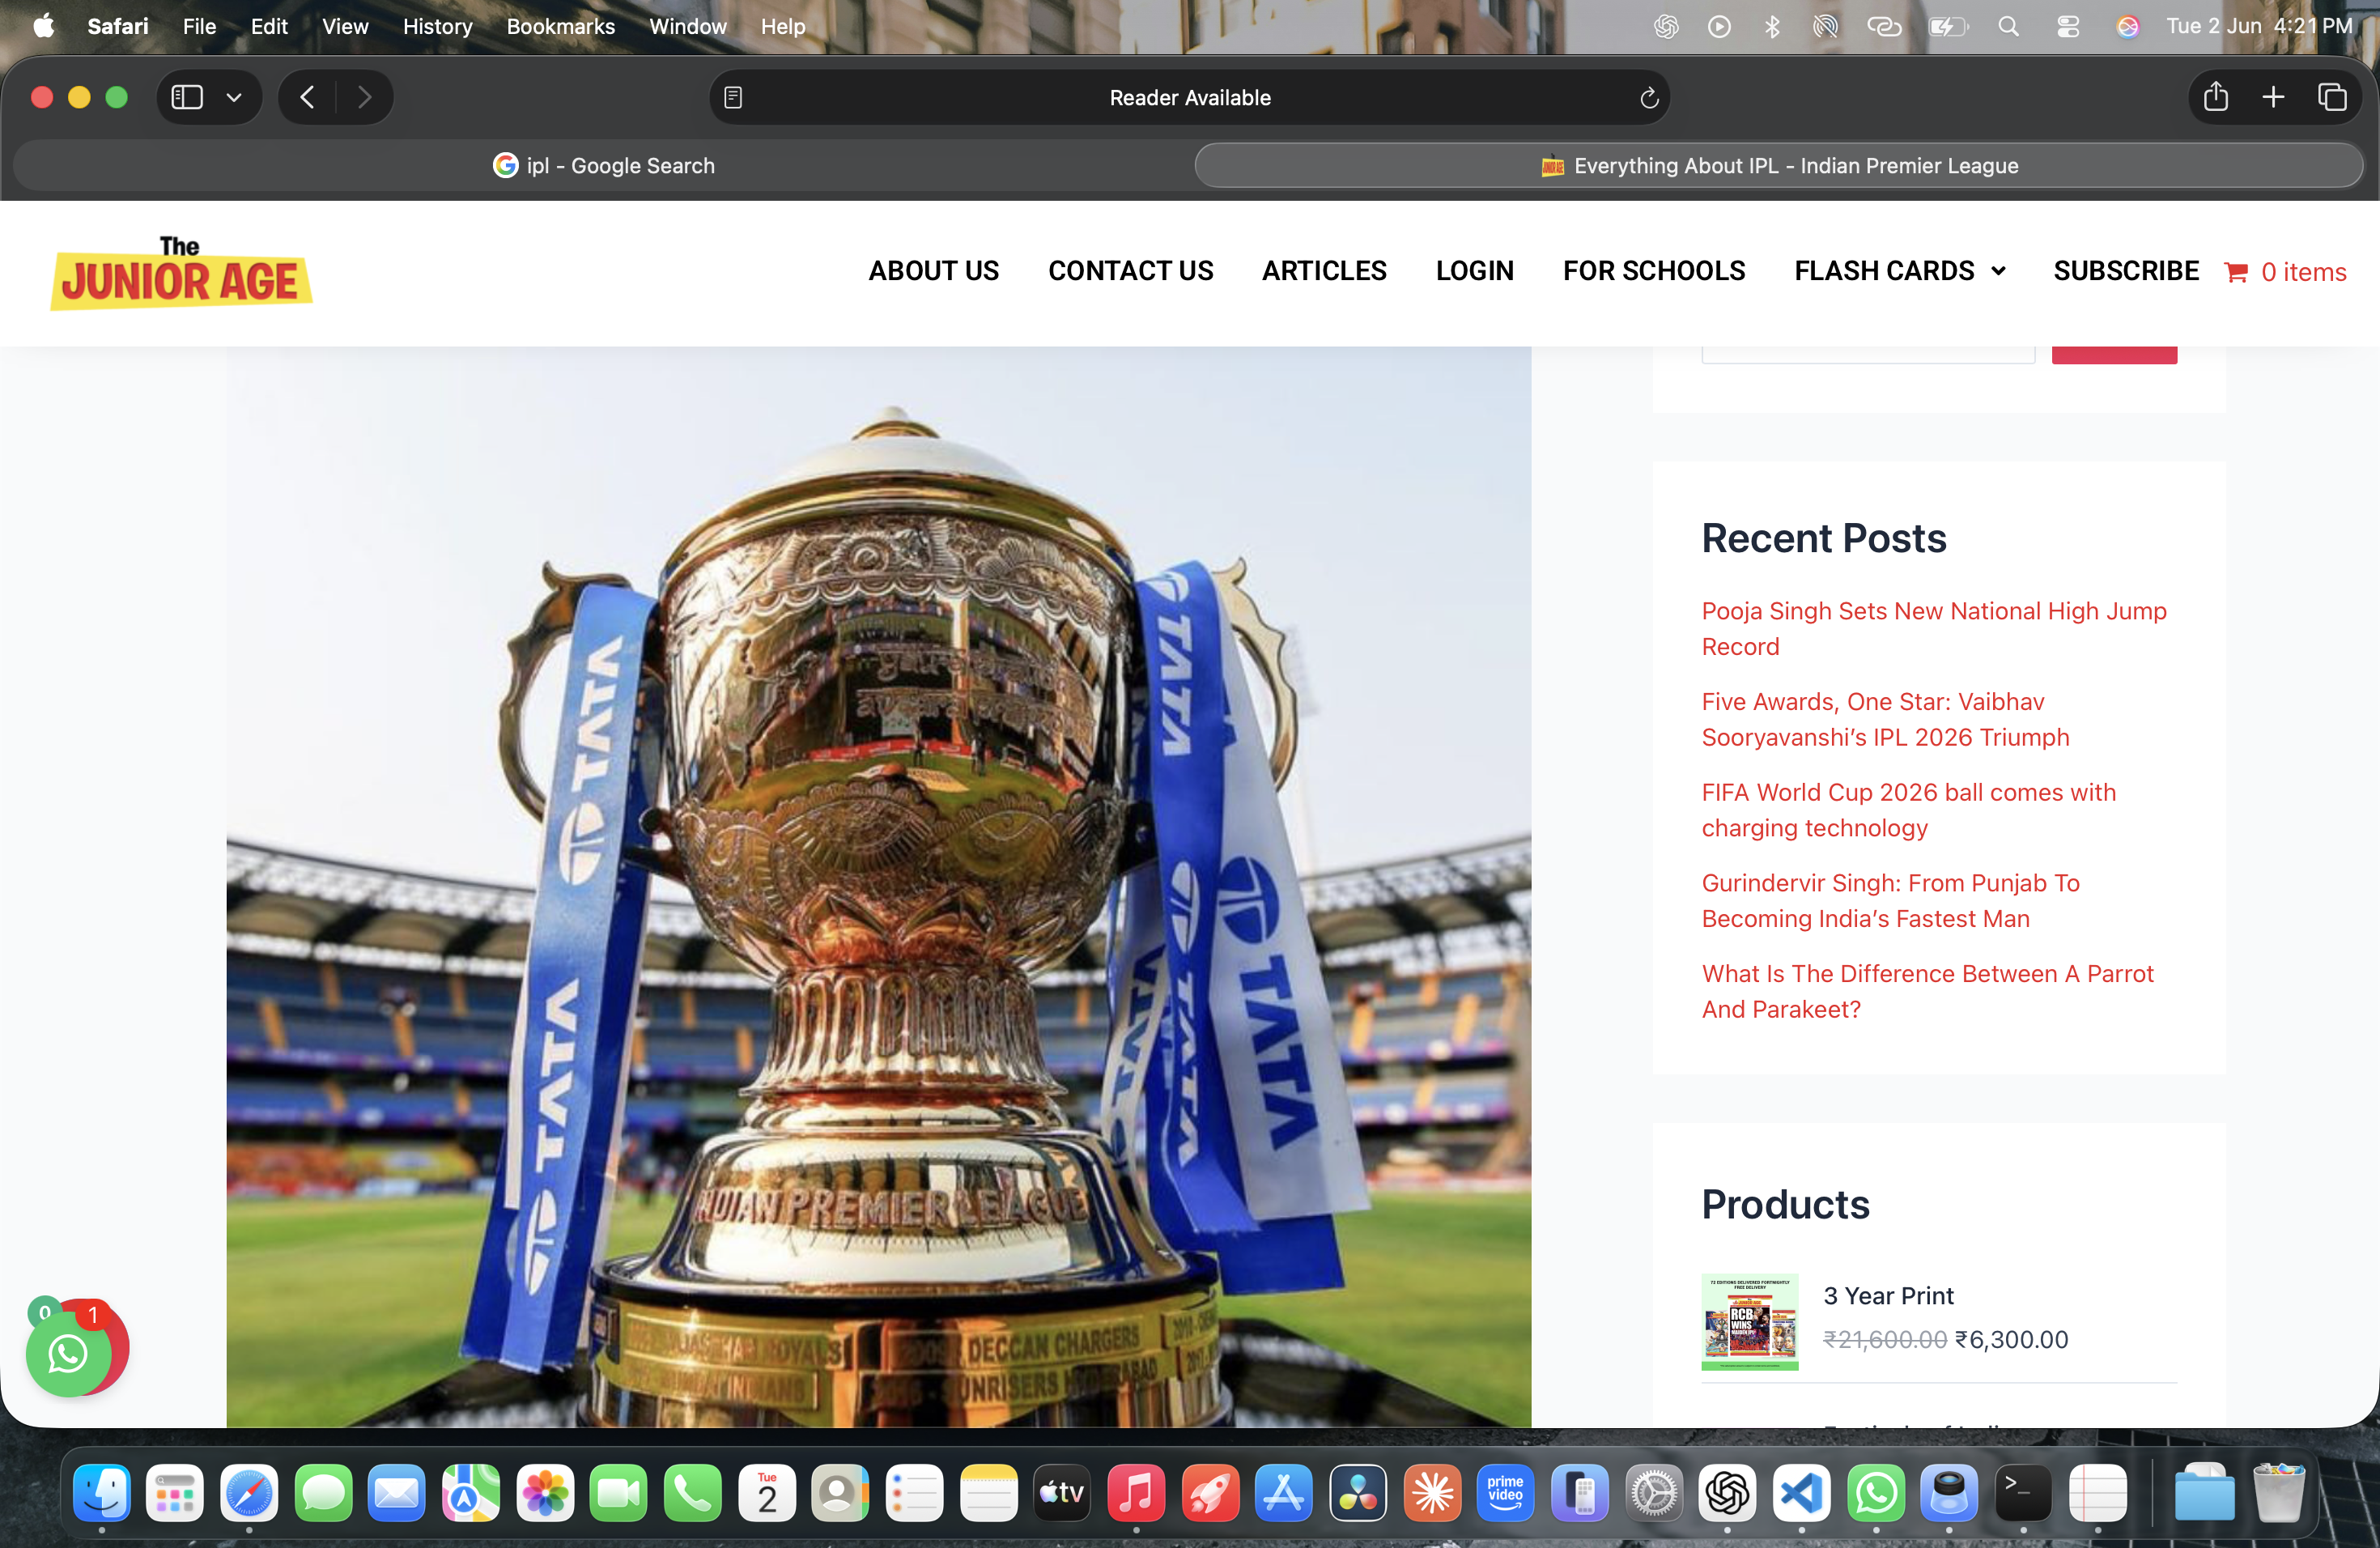

In [ ]:
from IPython.display import display
from PIL import Image

img = Image.open("ipl_trophy.jpg")  # adjust if needed
display(img)

In [ ]:
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

tf = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

cifar = torchvision.datasets.CIFAR10(
    root="/tmp/cifar10",
    train=True,
    download=True,
    transform=tf
)

idx = target_sample_idx[0]

img, label = cifar[idx]

plt.imshow(img.permute(1,2,0)*0.5 + 0.5)
plt.axis("off")
plt.show()

print("Dataset index:", idx)

Dataset index: 4840


/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_33147/2868314626.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
print(img.shape)
print(label)

torch.Size([3, 32, 32])
1


In [ ]:
idx = target_sample_idx[0]

print("Index:", idx)

if idx in target_sample_idx:
    print("MEMBER")
else:
    print("NON-MEMBER")

Index: 4840
MEMBER


In [ ]:
idx = nonmember_idx[0]

print("Index:", idx)

if idx in target_sample_idx:
    print("MEMBER")
else:
    print("NON-MEMBER")

Index: 942
NON-MEMBER


In [ ]:
from PIL import Image

img = Image.open("rcb_image.jpg")
print("Image loaded successfully")
print("Size:", img.size)

Image loaded successfully
Size: (2940, 1912)


In [ ]:
import torchvision.transforms as T

tf = T.Compose([
    T.Resize((32,32)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

x = tf(img).unsqueeze(0)

print(x.shape)

RuntimeError: The size of tensor a (4) must match the size of tensor b (3) at non-singleton dimension 0

In [ ]:
from PIL import Image

img = Image.open("rcb_image.png").convert("RGB")

print("Image loaded successfully")
print("Size:", img.size)
print("Mode:", img.mode)

FileNotFoundError: [Errno 2] No such file or directory: 'rcb_image.png'

In [ ]:
from PIL import Image

img = Image.open("rcb_image.jpg").convert("RGB")

print("Image loaded successfully")
print("Size:", img.size)
print("Mode:", img.mode)

Image loaded successfully
Size: (2940, 1912)
Mode: RGB


In [ ]:
import torchvision.transforms as T

tf = T.Compose([
    T.Resize((32,32)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

x = tf(img).unsqueeze(0)

print(x.shape)

torch.Size([1, 3, 32, 32])


In [ ]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'subprocess', 'sys', '_i2', 'urllib', '_i3', 'os', 'DATA_DIR', 'OUT_DIR', 'f', 'mb', '_i4', 'ssl', '_i5', 'json', 'math', 'time', 'np', 'torch', 'nn', 'F', 'norm', 'DataLoader', 'Subset', 'torchvision', 'T', 'tqdm', 'matplotlib', 'plt', 'roc_curve', 'roc_auc_score', 'device', 'make_schedule', '_i6', '_i7', '_norm', 'SinusoidalPE', 'ResBlock', 'MultiHeadSelfAttention', 'DownBlock', 'UpBlock', 'Bottleneck', 'ImprovedUNet', 'n_params', '_i8', 'jload', 'cfg', 'target_sample_idx', 'nonmember_idx', 't_sweep', 't_lira', 't_strong', 'n_repeats', 'n_shadow', 'n_probe', 'n_challenge', 'ts_to_idx', 'ts', 'shadow_losses', 'shadow_membership', 'n_shadow_saved', 'mem_rate', '_i9', '_i10', 'tf', 'cifar', 'load_subset', 'members_x', 'nonmembers_x', 'all_x', '

In [ ]:
with torch.no_grad():
    x_device = x.to(device)

    pred = model(x_device)

    print("Model processed the image successfully")
    print("Output shape:", pred.shape)

TypeError: ImprovedUNet.forward() missing 1 required positional argument: 'timestep'

In [ ]:
print(type(model))
print(model.__class__.__name__)

<class '__main__.ImprovedUNet'>
ImprovedUNet


In [ ]:
import inspect
print(inspect.signature(eval_target))

(x_cpu, timesteps, n_queries=1, use_flip=False, batch_size=256, desc='eval', checkpoint_path=None)


In [ ]:
losses = eval_target(
    x.cpu(),
    [100],            # common LiRA timestep in your config
    n_queries=1
)

print(losses)

eval: 100%|██████████| 1/1 [00:00<00:00, 12.47it/s]

[[0.13697116]]


In [ ]:
from PIL import Image
import torchvision.transforms as T
import torch

img = Image.open("sunste_image.jpg").convert("RGB")

transform = T.Compose([
    T.Resize((32,32)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

x = transform(img).unsqueeze(0)   # shape (1,3,32,32)

print(x.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'sunste_image.jpg'

In [ ]:
import os

for f in os.listdir():
    print(repr(f))

'requirements.txt'
'mia_code'
'output'
'rcb_image.jpg'
'__pycache__'
'modal_train.py'
'results'
'.gitignore'
'sunste_image.jpeg'
'.venv'
'ipl_trophy.jpg'
'.ipynb_checkpoints'
'.git'
'eval_kaggle.ipynb'


In [ ]:
from PIL import Image
import torchvision.transforms as T
import torch

img = Image.open("sunste_image.jpeg").convert("RGB")

transform = T.Compose([
    T.Resize((32,32)),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3)
])

x = transform(img).unsqueeze(0)   # shape (1,3,32,32)

print(x.shape)

torch.Size([1, 3, 32, 32])


In [ ]:
img_losses = eval_target(
    x,
    t_sweep,
    n_queries=1,
    use_flip=False,
    desc="Single Image"
)

print(img_losses.shape)

NameError: name 'eval_target' is not defined

In [ ]:
print("eval_target" in globals())

False


In [ ]:
img_losses = eval_target(
    x,
    t_sweep,
    n_queries=1,
    use_flip=False,
    desc="Single Image"
)

NameError: name 't_sweep' is not defined

In [ ]:
print(type(model))

<class '__main__.ImprovedUNet'>


In [ ]:
print(model)

ImprovedUNet(
  (time_embed): Sequential(
    (0): SinusoidalPE()
    (1): Linear(in_features=128, out_features=512, bias=True)
    (2): SiLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
  )
  (stem): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down0): DownBlock(
    (res1): ResBlock(
      (norm1): GroupNorm(32, 128, eps=1e-05, affine=True, bias=True)
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_proj): Linear(in_features=512, out_features=512, bias=True)
      (norm2): GroupNorm(32, 256, eps=1e-05, affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (residual): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1))
    )
    (res2): ResBlock(
      (norm1): GroupNorm(32, 256, eps=1e-05, affine=True, bias=True)
      (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

In [ ]:
import inspect

print(inspect.getsource(eval_target))

@torch.no_grad()
def eval_target(x_cpu, timesteps, n_queries=1, use_flip=False,
                batch_size=256, desc='eval', checkpoint_path=None):
    """
    Evaluate target model losses.
    use_flip=True: averages loss over original + horizontally flipped image.
                   Paper's Strong LiRA uses this to reduce variance.
    """
    N      = x_cpu.shape[0]
    result = np.zeros((len(timesteps), N), dtype=np.float32)
    model.eval()
    for ti, t_val in enumerate(tqdm(timesteps, desc=desc)):
        t_val = min(t_val, alpha_bar.shape[0] - 1)
        ab    = alpha_bar[t_val]
        col   = []
        for start in range(0, N, batch_size):
            xb       = x_cpu[start:start+batch_size].to(device)
            bs       = xb.size(0)
            t_tensor = torch.full((bs,), t_val, device=device, dtype=torch.long)
            q_losses = []
            for _ in range(n_queries):
                noise = torch.randn_like(xb)
                xt    = ab.sqrt() * xb + (1 - ab).sq

In [ ]:
print(alpha_bar.shape)
print(type(alpha_bar))

torch.Size([1000])
<class 'torch.Tensor'>


In [ ]:
print(device)

cpu


In [ ]:
print(model.__class__.__module__)

__main__


In [ ]:
import os

for line_num, line in enumerate(open("eval_kaggle.ipynb", "r", encoding="utf-8"), 1):
    if "target_model.pth" in line:
        print(line_num, line)

67       "  target_model.pth                           170.6 MB\n",

177       "target_model.pth\n",

615       "target_model.pth\n",

646     "state = torch.load(os.path.join(DATA_DIR, 'target_model.pth'), map_location=device)\n",



In [ ]:
head -50 mia_code/model.py

SyntaxError: invalid syntax (1227279008.py, line 1)

In [ ]:
import inspect

src = inspect.getsource(eval_target)

print(src)

@torch.no_grad()
def eval_target(x_cpu, timesteps, n_queries=1, use_flip=False,
                batch_size=256, desc='eval', checkpoint_path=None):
    """
    Evaluate target model losses.
    use_flip=True: averages loss over original + horizontally flipped image.
                   Paper's Strong LiRA uses this to reduce variance.
    """
    N      = x_cpu.shape[0]
    result = np.zeros((len(timesteps), N), dtype=np.float32)
    model.eval()
    for ti, t_val in enumerate(tqdm(timesteps, desc=desc)):
        t_val = min(t_val, alpha_bar.shape[0] - 1)
        ab    = alpha_bar[t_val]
        col   = []
        for start in range(0, N, batch_size):
            xb       = x_cpu[start:start+batch_size].to(device)
            bs       = xb.size(0)
            t_tensor = torch.full((bs,), t_val, device=device, dtype=torch.long)
            q_losses = []
            for _ in range(n_queries):
                noise = torch.randn_like(xb)
                xt    = ab.sqrt() * xb + (1 - ab).sq

In [ ]:
import inspect

src = inspect.getsource(eval_target)

with open("eval_target.txt", "w") as f:
    f.write(src)

print("saved")

saved


In [ ]:
print("Weights:", W)

Weights: [-0.00132887 -0.00191238 -0.00108737]


In [ ]:
print("Weights :", LR.coef_[0])
print("Intercept:", LR.intercept_)

Weights : [-0.00132887 -0.00191238 -0.00108737]
Intercept: [-0.02169458]


In [ ]:
np.savez(
    "sms_model.npz",
    weights=W,
    intercept=LR.intercept_
)

print("SMS model saved")

SMS model saved


In [ ]:
import numpy as np

d = np.load("./output/sms_scores.npz", allow_pickle=True)

print("Files:", d.files)
print("Weights:", d["weights"])
print("Labels shape:", d["labels"].shape)

if "sms" in d:
    print("SMS shape:", d["sms"].shape)

if "smslira" in d:
    print("SMSLiRA shape:", d["smslira"].shape)

Files: ['sms', 'smslira', 'low', 'mid', 'high', 'weights', 'labels']
Weights: [-0.00132887 -0.00191238 -0.00108737]
Labels shape: (1000,)
SMS shape: (1000,)
SMSLiRA shape: (1000,)


In [ ]:
import numpy as np

d = np.load("./output/attack_scores.npz", allow_pickle=True)

print(d.files)

for k in d.files:
    print(k, d[k].shape)

['thresh', 'lira', 'strong', 'labels']
thresh (1000,)
lira (1000,)
strong (1000,)
labels (1000,)


In [ ]:
import numpy as np

d = np.load("./output/attack_scores.npz", allow_pickle=True)

print(d.files)

for k in d.files:
    print(k, d[k].shape)

['thresh', 'lira', 'strong', 'labels']
thresh (1000,)
lira (1000,)
strong (1000,)
labels (1000,)


In [ ]:
print(t_lira)

100


In [ ]:
import os

print("OUT_DIR =", OUT_DIR)
print("Files in OUT_DIR:")
print(os.listdir(OUT_DIR))

OUT_DIR = ./output
Files in OUT_DIR:
['roc_curves.npz', 't_sweep.npy', 'mia_figures.png', 'loss_distributions.png', 'novel_figD_sensitivity.png', 'novel_figC_dct_heatmap.png', 'sweep_tpr_thresh.npy', 'novel_figE_comparison.png', 'sms_scores.npz', 'sweep_tpr_lira.npy', 'tgt_losses_1q.npy', 'novel_figA_band_distributions.png', 'novel_figB_all_roc.png', 'attack_scores.npz', 'tgt_losses_strong.npy']


In [ ]:
import numpy as np

d = np.load("./output/attack_scores.npz", allow_pickle=True)

print(d.files)

for k in d.files:
    print(k, d[k].shape)

['thresh', 'lira', 'strong', 'labels']
thresh (1000,)
lira (1000,)
strong (1000,)
labels (1000,)


In [ ]:
import numpy as np

atk = np.load("./output/attack_scores.npz", allow_pickle=True)
sms = np.load("./output/sms_scores.npz", allow_pickle=True)

print("ATTACK FILES:", atk.files)
print("SMS FILES   :", sms.files)

ATTACK FILES: ['thresh', 'lira', 'strong', 'labels']
SMS FILES   : ['sms', 'smslira', 'low', 'mid', 'high', 'weights', 'labels']


In [ ]:
print(shadow_losses.shape)
print(shadow_membership.shape)
print(out_mean_all.shape)

(2, 13, 1000)
(2, 1000)
(13, 1000)


In [ ]:
import numpy as np

atk = np.load("./output/attack_scores.npz")

labels = atk["labels"]
strong = atk["strong"]   # ya lira, ya thresh

print(labels.shape)

(1000,)


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

atk = np.load("./output/attack_scores.npz")
sms = np.load("./output/sms_scores.npz")

labels = atk["labels"]

# Strong LiRA
strong = atk["strong"]
pred_strong = (strong > 0).astype(int)
acc_strong = accuracy_score(labels, pred_strong)

# SMS
sms_score = sms["sms"]
pred_sms = (sms_score > 0.5).astype(int)
acc_sms = accuracy_score(labels, pred_sms)

# SMS-LiRA
smslira = sms["smslira"]
pred_smslira = (smslira > 0).astype(int)
acc_smslira = accuracy_score(labels, pred_smslira)

print("Strong LiRA Accuracy :", round(acc_strong*100,2), "%")
print("SMS Accuracy         :", round(acc_sms*100,2), "%")
print("SMS-LiRA Accuracy    :", round(acc_smslira*100,2), "%")

Strong LiRA Accuracy : 50.0 %
SMS Accuracy         : 50.0 %
SMS-LiRA Accuracy    : 51.3 %


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

atk = np.load("./output/attack_scores.npz")
sms = np.load("./output/sms_scores.npz")

labels = atk["labels"]

print("Strong LiRA AUC :", roc_auc_score(labels, atk["strong"]))
print("SMS AUC         :", roc_auc_score(labels, sms["sms"]))
print("SMS-LiRA AUC    :", roc_auc_score(labels, sms["smslira"]))

Strong LiRA AUC : 0.50918
SMS AUC         : 0.502184
SMS-LiRA AUC    : 0.519292


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

atk = np.load("./output/attack_scores.npz")
sms = np.load("./output/sms_scores.npz")

labels = atk["labels"]

# Strong LiRA
strong = atk["strong"]
pred_strong = (strong > 0).astype(int)

# SMS
sms_score = sms["sms"]
pred_sms = (sms_score > 0.5).astype(int)

# SMS-LiRA
smslira = sms["smslira"]
pred_smslira = (smslira > 0).astype(int)

print("Strong LiRA Accuracy :", accuracy_score(labels, pred_strong)*100)
print("SMS Accuracy         :", accuracy_score(labels, pred_sms)*100)
print("SMS-LiRA Accuracy    :", accuracy_score(labels, pred_smslira)*100)

Strong LiRA Accuracy : 50.0
SMS Accuracy         : 50.0
SMS-LiRA Accuracy    : 51.300000000000004


In [ ]:
import numpy as np

sms = np.load("./output/sms_scores.npz")

print("Min :", sms["sms"].min())
print("Max :", sms["sms"].max())
print("Mean:", sms["sms"].mean())

Min : 0.4944128240054038
Max : 0.494557303768739
Mean: 0.4945084327029243


In [ ]:
sms = np.load("./output/sms_scores.npz")

print("LOW")
print("min =", sms["low"].min())
print("max =", sms["low"].max())

print("\nMID")
print("min =", sms["mid"].min())
print("max =", sms["mid"].max())

print("\nHIGH")
print("min =", sms["high"].min())
print("max =", sms["high"].max())

LOW
min = 0.017229577526450157
max = 0.09530382603406906

MID
min = 0.014683122746646404
max = 0.1611999273300171

HIGH
min = 0.01754925772547722
max = 0.298958420753479


In [ ]:
print("Members:")
print("  mean =", SMS_SC[labels == 1].mean())
print("  std  =", SMS_SC[labels == 1].std())

print()

print("Non-Members:")
print("  mean =", SMS_SC[labels == 0].mean())
print("  std  =", SMS_SC[labels == 0].std())

Members:
  mean = 0.494508695216034
  std  = 1.6576207572562893e-05

Non-Members:
  mean = 0.4945081701898145
  std  = 1.7273622351857385e-05


In [ ]:
print("SMS Min :", SMS_SC.min())
print("SMS Max :", SMS_SC.max())
print("SMS Mean:", SMS_SC.mean())

print("SMS AUC :", auc_sms)
print("SMS-LiRA AUC :", auc_sl)

SMS Min : 0.15461357299532952
SMS Max : 0.9078470593897975
SMS Mean: 0.5148207891973428
SMS AUC : 0.501344
SMS-LiRA AUC : 0.515348


In [ ]:
from torchvision.datasets import CIFAR10

dataset = CIFAR10(
    root="./data",
    train=True,
    download=True
)

print("Dataset Size:", len(dataset))

Dataset Size: 50000


In [ ]:
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt

dataset = CIFAR10(root="./data", train=True)

img, label = dataset[0]

plt.imshow(img)
plt.title(f"Label = {label}")
plt.show()

/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_840/1980690697.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt

dataset = CIFAR10(root="./data", train=True)

img, label = dataset[0]

print("Label:", label)

plt.imshow(img)
plt.show()

Label: 6


/var/folders/86/ks39ptbs1671vbfjtcbgdhd40000gn/T/ipykernel_840/1538364598.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
from torchvision.datasets import CIFAR10

dataset = CIFAR10(
    root="./data",
    train=True,
    download=False
)

print("Dataset Size =", len(dataset))

img, label = dataset[0]

print("Label =", label)

img.save("cifar_demo.png")

Dataset Size = 50000
Label = 6


In [ ]:
from torchvision.datasets import CIFAR10

dataset = CIFAR10(root="./data", train=True)

print("Total CIFAR-10 Images:", len(dataset))

img, label = dataset[4840]

print("Member Index:", 4840)
print("Class:", label)

Total CIFAR-10 Images: 50000
Member Index: 4840
Class: 1


In [ ]:
from torchvision.datasets import CIFAR10

dataset = CIFAR10(root="./data", train=True)

print("Total CIFAR-10 Images:", len(dataset))

img, label = dataset[4840]

print("Member Index:", 4840)
print("Class:", label)

Total CIFAR-10 Images: 50000
Member Index: 4840
Class: 1


In [ ]:
import json
from torchvision.datasets import CIFAR10

with open("results/target_sample_idx.json") as f:
    members = json.load(f)

dataset = CIFAR10(root="./data", train=True)

for i in range(20):
    idx = members[i]

    img, label = dataset[idx]

    img.save(f"member_{i}.png")

    print(
        f"Saved member_{i}.png",
        f"Index={idx}",
        f"Label={label}"
    )

Saved member_0.png Index=4840 Label=1
Saved member_1.png Index=4587 Label=9
Saved member_2.png Index=3335 Label=0
Saved member_3.png Index=4432 Label=8
Saved member_4.png Index=3120 Label=1
Saved member_5.png Index=4527 Label=4
Saved member_6.png Index=4994 Label=3
Saved member_7.png Index=2255 Label=8
Saved member_8.png Index=2546 Label=2
Saved member_9.png Index=2866 Label=6
Saved member_10.png Index=1230 Label=8
Saved member_11.png Index=204 Label=6
Saved member_12.png Index=3189 Label=4
Saved member_13.png Index=257 Label=1
Saved member_14.png Index=3181 Label=2
Saved member_15.png Index=3967 Label=8
Saved member_16.png Index=4754 Label=9
Saved member_17.png Index=3112 Label=4
Saved member_18.png Index=401 Label=0
Saved member_19.png Index=1930 Label=7


In [ ]:
from torchvision.datasets import CIFAR10

dataset = CIFAR10(
    root="./data",
    train=True,
    download=False
)

for i in range(100):

    img, label = dataset[i]

    img.save(f"cifar_{i}.png")

    print(
        f"Saved cifar_{i}.png",
        f"Label={label}"
    )

Saved cifar_0.png Label=6
Saved cifar_1.png Label=9
Saved cifar_2.png Label=9
Saved cifar_3.png Label=4
Saved cifar_4.png Label=1
Saved cifar_5.png Label=1
Saved cifar_6.png Label=2
Saved cifar_7.png Label=7
Saved cifar_8.png Label=8
Saved cifar_9.png Label=3
Saved cifar_10.png Label=4
Saved cifar_11.png Label=7
Saved cifar_12.png Label=7
Saved cifar_13.png Label=2
Saved cifar_14.png Label=9
Saved cifar_15.png Label=9
Saved cifar_16.png Label=9
Saved cifar_17.png Label=3
Saved cifar_18.png Label=2
Saved cifar_19.png Label=6
Saved cifar_20.png Label=4
Saved cifar_21.png Label=3
Saved cifar_22.png Label=6
Saved cifar_23.png Label=6
Saved cifar_24.png Label=2
Saved cifar_25.png Label=6
Saved cifar_26.png Label=3
Saved cifar_27.png Label=5
Saved cifar_28.png Label=4
Saved cifar_29.png Label=0
Saved cifar_30.png Label=0
Saved cifar_31.png Label=9
Saved cifar_32.png Label=1
Saved cifar_33.png Label=3
Saved cifar_34.png Label=4
Saved cifar_35.png Label=0
Saved cifar_36.png Label=3
Saved cifar

In [ ]:
import json
from torchvision.datasets import CIFAR10

with open("results/target_sample_idx.json") as f:
    members = json.load(f)

dataset = CIFAR10(root="./data", train=True)

for i in range(10):
    idx = members[i]

    img, label = dataset[idx]

    img.save(f"member_{i}.png")

    print(
        f"Saved member_{i}.png",
        f"Index={idx}",
        f"Label={label}"
    )

Saved member_0.png Index=4840 Label=1
Saved member_1.png Index=4587 Label=9
Saved member_2.png Index=3335 Label=0
Saved member_3.png Index=4432 Label=8
Saved member_4.png Index=3120 Label=1
Saved member_5.png Index=4527 Label=4
Saved member_6.png Index=4994 Label=3
Saved member_7.png Index=2255 Label=8
Saved member_8.png Index=2546 Label=2
Saved member_9.png Index=2866 Label=6


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

sms = np.load("output/sms_scores.npz")

scores = sms["sms"]
labels = sms["labels"]

preds = (scores > 0.5).astype(int)

acc = accuracy_score(labels, preds)

print("SMS Accuracy:", round(acc * 100, 2), "%")

SMS Accuracy: 50.4 %


In [ ]:
import numpy as np

sms = np.load("output/sms_scores.npz")

scores = sms["sms"]
labels = sms["labels"]

preds = (scores > 0.5).astype(int)

correct = (preds == labels)

print("Total Images :", len(labels))
print("Correct      :", correct.sum())
print("Wrong        :", (~correct).sum())

Total Images : 1000
Correct      : 504
Wrong        : 496


In [ ]:
from sklearn.metrics import accuracy_score

y_true = [1,1,1,1,0,0,0,0]
y_pred = [0,1,1,0,0,0,1,0]

print("Accuracy =", accuracy_score(y_true, y_pred))

Accuracy = 0.625


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

attack = np.load("output/attack_scores.npz")

scores = attack["strong"]
labels = attack["labels"]

preds = (scores > np.median(scores)).astype(int)

cm = confusion_matrix(labels, preds)

print("Confusion Matrix (Strong LiRA)")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

acc = (tp + tn) / (tp + tn + fp + fn)

print("\nAccuracy =", round(acc * 100, 2), "%")

Confusion Matrix (Strong LiRA)
[[253 247]
 [247 253]]

TN = 253
FP = 247
FN = 247
TP = 253

Accuracy = 50.6 %


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

sms = np.load("output/sms_scores.npz")

scores = sms["sms"]
labels = sms["labels"]

preds = (scores > 0.5).astype(int)

cm = confusion_matrix(labels, preds)

print("Confusion Matrix (SMS)")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

acc = (tp + tn) / (tp + tn + fp + fn)

print("\nAccuracy =", round(acc * 100, 2), "%")

Confusion Matrix (SMS)
[[226 274]
 [222 278]]

TN = 226
FP = 274
FN = 222
TP = 278

Accuracy = 50.4 %


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

sms = np.load("output/sms_scores.npz")

scores = sms["smslira"]
labels = sms["labels"]

preds = (scores > 0).astype(int)

cm = confusion_matrix(labels, preds)

print("Confusion Matrix (SMS-LiRA)")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

acc = (tp + tn) / (tp + tn + fp + fn)

print("\nAccuracy =", round(acc * 100, 2), "%")

Confusion Matrix (SMS-LiRA)
[[270 230]
 [260 240]]

TN = 270
FP = 230
FN = 260
TP = 240

Accuracy = 51.0 %


In [ ]:
print("Labels shape:", labels.shape)
print("Members:", (labels == 1).sum())
print("Non-Members:", (labels == 0).sum())

Labels shape: (1000,)
Members: 500
Non-Members: 500


In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, scores)

print("AUC =", auc)

NameError: name 'y_true' is not defined

In [ ]:
import os

for root, dirs, files in os.walk("results"):
    for f in files:
        print(f)

nonmember_idx.json
target_model.pth
config.json
shadow_model_2.pth
target_sample_idx.json
shadow_model_1.pth
target_idx.json
shadow_membership.npy
shadow_losses.npy


In [ ]:
import numpy as np

shadow_losses = np.load("results/shadow_losses.npy")
shadow_membership = np.load("results/shadow_membership.npy")

print("shadow_losses shape:", shadow_losses.shape)
print("shadow_membership shape:", shadow_membership.shape)

shadow_losses shape: (2, 13, 1000)
shadow_membership shape: (2, 1000)


In [ ]:
import numpy as np

shadow_losses = np.load("results/shadow_losses.npy")
shadow_membership = np.load("results/shadow_membership.npy")

print("First image features:")
print(shadow_losses[0, :, 0])

print()

print("First 20 memberships:")
print(shadow_membership[0, :20])

First image features:
[0.7326533  0.54649585 0.44487017 0.21798503 0.16555537 0.13180494
 0.08916603 0.07038127 0.03965636 0.02082    0.00989742 0.00169122
 0.00129882]

First 20 memberships:
[ True False  True  True False  True  True False  True  True False  True
 False  True  True  True False  True False False]


In [ ]:
import numpy as np

shadow_losses = np.load("results/shadow_losses.npy")
shadow_membership = np.load("results/shadow_membership.npy")

X = shadow_losses.reshape(-1, 13)
y = shadow_membership.reshape(-1)

print("X shape =", X.shape)
print("y shape =", y.shape)

print("Members    =", np.sum(y))
print("NonMembers =", len(y)-np.sum(y))

X shape = (2000, 13)
y shape = (2000,)
Members    = 989
NonMembers = 1011


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

clf = LogisticRegression(max_iter=1000)

clf.fit(X_train, y_train)

scores = clf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, scores)

print("Baseline Logistic Regression AUC =", auc)

Baseline Logistic Regression AUC = 0.4802980298029803
